# Can the deshape synchrosqueezing transform (dsSST) extract the walk instantaneous frequency from accelerometer data of stroke patients with sensors on the wrist, feet and sacrum ?

Authors : Camille LAMBERT
Co-authors : Claude IA, Copilot IA

## 0. Available data and code
The data used in this work is from the article of Zhou et al., « Dataset for Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors (IMU) ». The dataset is available in https://zenodo.org/records/10534055  
The code is available at the address https://github.com/lambertwcamille-source/LAMBERT_CAMILLE.git  

### 1. Scientific problem

### 1.1. Context
The de shape synchrosqueezing transform (dsSST) extracts the instantaneous frequency of a signal by a combination of two non-linear operations, the de shape operation and the synchrosqueezing operation. This reliable technique for extracting the instantaneous frequency of a sustained harmonic walk can be used in future work to extract the period of the walk from the harmonic component of the signal. (Wu et al., 2023)
The application of this technique on the stroke patient stills need to be done. The asymmetric walk and the specificity of the hemiplegic gait can be a limitation in the futur use of this tool.

### 1.2. Research question

The research question behind this work is: Is the detection of walk instantaneous frequency by the deshape synchrosqueezing on acceleration data the same, for sensor position on the wrist in comparison with sensor on the feet for stroke patient who can walk without physical assistance ?

### 1.2. Goal of the work

The goal of this work is to assess the capacity of the dsSST algorithm to find the instantaneous frequency from accelerometer data of a sensor worn on the feet, wrists or sacrum of a stroke patient.

### 1.3. Method

The deshape synchrosqueezing transform is a powerful tool to extract the instantaneous frequency of a sustained harmonic walk from accelerometer data. The pipeline used in this work has been done from the article of Wu et Harezlak, « Application of de-shape synchrosqueezing to estimate gait cadence from a single-sensor accelerometer placed in different body locations ».
Changes have been made to stabilise the short time ceptrum transform with the implementation of a long pass filter. This method is based on the article of Lin et al., « Wave-Shape Function Analysis -- When Cepstrum Meets Time-Frequency Analysis».  
Fig 1 illustration of the steps of the pipeline used in this work.  
![Pipeline](step_dssst.png)  

### 1.4. Participant

This work is based on the dataset of Zhou and all. It’s a dataset of 10 stroke patients in an acute phase.  

The inclusion criteria are “To have the cardiorespiratory capacity to walk on a short distance, to don’t have other conditions than stroke who limited the gait”.  

The exclusion criteria are “pronounced chronic obstructive pulmonary disease or heart failure requiring oxygen dependency; knee or hip replacement, orthopaedics injuries or orthopaedic-related pain that impairs gait; pre-existing, severe neuropathy that causes a gait disorder; and gait disorders that are not attributable to a stroke.”  

The patients were monitored during two visits who were spaced for one or two weeks. The first visit was a week after the stoking. In a function of the patient capacity, they had to walk between 60m to 200m in a 10m hallway.  The patient was monitored by Five IMUs (Xsens DOT, Xsens Technologies B.V., the Netherlands, https://www.xsens.com/wearables/xsens-dot).  
Place on both feet and both wrists and the sacrum (Annexe 1). The IMUs give use the information of triaxial acceleration (range: ± 16 g) and angular velocity (range: ± 1000 degrees/s) with a sampling rate of 120 Hz.  

### 1.5. Results
The results show us that the sensor's location doesn't have a significant impact on the ability to find the instantaneous frequency of the walk with the dsSST algorithm.

## Data organisation

In this directory you have the data of one patient during two visits.
Each visit has 
    _RF:Right foot
    _LF:Left foot
    _RW:Right wrist
    _LW:Left wrist
    _SA:Sacrum
    

## Python project organisation

This folder has been made with the help of the work of Victor Fernando Lopes De Souza, who made the GitHub activity_acc_clustering

The code construction has been helping a lot with the co-pilot IA and Claude IA.

In this folder you will find a python directory that contains the code for handling the data information and extracting the instantaneous frequency from the dsSST pipeline .  

In the directory module, you have the handle_data.ipynb  
    Aim : extract the data and process them  
    Input : the parameters of the deshape synchrosqueezing pipeline and the path of the data  
    Output : the instantaneous frequency of the walk for each sensor location and each visit.  
  
In the directory module, you have the dsSST.ipynb  
    Aim : extract the instantaneous frequency of the walk from the deshape synchrosqueezing   pipeline   
    Input : the parameters of the deshape synchrosqueezing pipeline.  
    Output : the instantaneous frequency of the walk for each sensor location and each visit.  

In the notebook you have the notebook of the data visualisation and the statistical analysis of the results. The main result of this work is computed in this work.  
The pipeline is made with the synchrosqueezing function created by John Muradeli, ssqueezepy, 2020. GitHub repository, https://github.com/OverLordGoldDragon/ssqueezepy/. DOI: 10.5281/zenodo.5080508  

## Notebook construction

This notebook performs the following steps to analyse the cadence of walking using IMU data:
1. Upload the library and configure the analysis parameters, including the sampling frequency and figure display settings.
2. Load the dataset and processing the IMU signals.
  
  
This work has been made with the utilisation of Claude IA and Co Pilot IA.  
  
The time frequency  analysis is performed using the deshape synchrosqueezing transform (dsSST) algorithm, which allows us to extract the fundamental frequency of walking from the accelerometer signals. The construction of the pipeline is made from the article of Wu et Harezlak, « Application of de-shape synchrosqueezing to estimate gait cadence from a single-sensor accelerometer placed in different body locations ».   
  
This notebook is working with the dataset provided by Zhou et al., « Dataset for Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors (IMU) ». The patient walked with an IMU sensor on their wrist/feet/sacrum, and the data was collected during different visits. The goal of this analysis is to extract the fundamental frequency information from the IMU signals .  
  
The directory structure of the project is inspired by the work of Victor Fernando Lopes De Souza's activity_acc_clustering directory.



## 1. Import & Configuration
### *a)* Import the library  

In [ ]:
# ------------------a) Import the necessary libraries------------------*
import os
import sys 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# if needed, install the required libraries using pip
# !pip install matplotlib
# !pip install numpy
# !pip install pandas
# !pip install pathlib

#install the dsSST library from the GitHub repository of 

### *b)* Create the path for the project resources (data, modules, results)  

In [ ]:
# ------------------b) The path for the project resources (data, modules, results)-------------------
"""
We have segmented the project into different directories to keep it organised. 
The project root is the base directory that contains all the other directories and a folder structure for the data and the project is available in project_root. 
The module directory is where we will place our custom Python modules, and the data directory is where we will store our datasets. 
The results directory is where we will save any outputs or visualisations generated from our analysis.
"""

# Define the project root, module, and data directories
project_root = os.path.abspath('../..')
module_dir = os.path.join(project_root, 'python_Movement_analysis_project/module')
data_dir = os.path.join(project_root, 'python_Movement_analysis_project/data/imu0001')
participant_file = os.path.join(data_dir, 'participant_info.csv')
results_dir = os.path.join(project_root, 'results')


# the following lines add the project root and module directories to the Python path, allowing you to import custom modules from those locations
if project_root not in sys.path:
	sys.path.append(project_root)
if module_dir not in sys.path:
	sys.path.append(module_dir)

# Import custom modules 
import dsSST
import handle_data

### *c)* Establish the parameters for the analysis, such as the sampling frequency and the sensors to analyse.  

In [ ]:
# ------------------c) Parameter for this analysis-------------------

# frequency of the data acquisition (sampling frequency) cf Zhou et al., « Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors ».
fs = 120  # Hz

# Sensors to analyse displayed in a list 
SENSORS = ["LF", "RF", "LW", "RW", "SA"]

# dsSST parameters (default values from the article Wu & Lin)
DSSST_PARAMS = dict(
    gamma=1e-9,
    lambda_reg=10**-3,
    lifter_threshold=60,
    window_length_s=12,   # STFT window size in seconds
)

# parameters for the visualization of the results
# Enable/disable figures per recording (can become heavy on large cohorts)
SAVE_FIGURES = True
SHOW_FIGURES_INLINE = True   # display in the notebook
MAX_INLINE_FIGURES = 1       # limit inline display to avoid overloading the notebook


## 2. Data extraction and processing
### *a)* data extraction with find_patient_visits function to get the list of patient visits and their corresponding data files. 
In the module handle_data, the function find_patient_visits scans the data directory for files and organises them into a structured format (e.g., a dictionary or DataFrame) .  

In [ ]:
#------------------a) data extraction ------------------
"""The first step in our analysis is to extract the relevant data from the dataset.
    ----------------------------INPUT----------------------------
    data_root: Path to the root directory of the dataset, which contains the patient directories (imuXXXX).
    ----------------------------OUTPUT----------------------------
    A list of dictionaries, each containing {patient_id, visit, imu_dir} for each valid patient visit found in the dataset.
"""

# Step 1 : Found the visits (use  find_patient_visits from the handle_data module)
Information_data_extraction = handle_data.find_patient_visits(Path(data_dir))
print(f"→ {len(Information_data_extraction)} visits found in the dataset")

# Step 2 : for each visit, list the expected sensors
recordings = []

for v in Information_data_extraction:
    for sensor in SENSORS:
        csv_path = v["imu_dir"] / f"{sensor}.csv"
        recordings.append({
            "visit":      v["visit"],
            "sensor":     sensor,
            "csv_path":   csv_path,
            "file_found": csv_path.exists(),
        })

# Visual summary of the data extraction step
n_total = len(recordings)
n_found = sum(r["file_found"] for r in recordings)
print(f"→ {n_found}/{n_total} fichiers CSV trouvés sur disque")

→ 2 visits found in the dataset
→ 10/10 fichiers CSV trouvés sur disque


### *b)* process the IMU signal to extract the Norm of acceleration and the time with the fucntion load_acc_norm.
From the data files found previously, the function load_acc_norm reads the accelerometer data, computes the norm of the acceleration , and extracts the corresponding time values.

In [ ]:
#------------------b) process the IMU signal to extract the norm of acceleration and the time------------------
"""The next step is to process the IMU signal to extract the norm of acceleration and the corresponding time values.
    ----------------------------INPUT----------------------------
    csv_path: Path to the csv file containing the raw data of the IMU sensor, which should be contained in the columns "timestamp", "accx", "accy", "accz"
    ----------------------------OUTPUT----------------------------
    ts: numpy array containing the time of the IMU sensor, extracted from the "timestamp" column of the csv file.
    norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
"""
    # First initialise the fields for each recording in the list of recordings, setting default values for the time series (ts), norm of acceleration (norm)
for rec in recordings:
    rec["ts"]         = None
    rec["norm"]       = None
    rec["n_samples"]  = np.nan
    rec["duration_s"] = np.nan
    rec["error"]      = ""

    # load the information need for the analysis
    try:
        ts, norm = handle_data.load_acc_norm(rec["csv_path"])
        rec["ts"]         = ts
        rec["norm"]       = norm
        rec["n_samples"]  = len(norm)
        rec["duration_s"] = len(norm) / fs


    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"

# Summary
n_loaded = sum(r["norm"] is not None and r["error"] == "" for r in recordings)
print(f"→ {n_loaded}/{n_total} signals loaded and usable")
print(f"→ {n_total - n_loaded} signals with errors (missing file, loading error, etc.)")

→ 10/10 signals loaded and usable
→ 0 signals with errors (missing file, loading error, etc.)


### *c)* Compute the time frequency analysis using the deshape synchrosqueezing transform (dsSST) with the function Time_frequency_analyse.
The function Time_frequency_analyse takes the norm of the acceleration and the time values as input and applies the dsSST algorithm to compute the time-frequency representation of the signal. This will give us the Short time Fourier transform of the signal, and the deshape synchrosqueezing transform of the signal, which will be used to extract the cadence information.  
Another function to illustrate the results of the analysis has been used is the compute_plot. It will save a figure for every patient with the norm of acceleration, the STFT and the dsSST. 

In [ ]:
#------------------c) Compute the time frequency analysis------------------
"""The next step is to compute the time-frequency analysis of the acceleration signal combining with a illustration of the results
   -----------------------------INPUT----------------------------
    signal_norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
    fs: sampling frequency of the IMU sensor
    dsSST_parameters : parameter to compute the deshape synchrosqueezing transform.
        It should contain the following keys:
        - "gamma": the gamma parameter of the dsSST is the threshold for the synchrosqueezing step
        - "lambda_reg": penelization parameter for the extraction by recurrence 
        - "lifter_threshold": the threshold for the lifting step, which is used to remove the low quefrency components of the signal.
        - "window_length_s": the length of the window used for the short-time Fourier transform (STFT) in seconds.
    -----------------------------OUTPUT----------------------------
    A dictionary containing the following keys:
    - "peak_frequency_hz": the fundamental frequency of the walk, extracted from the deshape synchrosqueezing transform of the signal.
    - "V_Zxx": the deshape synchrosqueezing transform of the signal, which is a time-frequency representation of the signal.
    - "V_f": the frequency axis of the deshape synchrosqueezing transform
    - "V_t": the time axis of the deshape synchrosqueezing transform
    - "Tx": the time-frequency representation of the signal obtained by applying the deshape synchrosqueezing transform
    - "freq_axis": the frequency axis of the deshape synchrosqueezing transform
    A figure illustrating the results of the analysis, which will be saved on the result directory for every patient
    - "fig"= the illustration of the norm of acceleration , the STFT, the dsSST. The number shown in control by

"""

inline_count = 0

for rec in recordings:
    rec["peak_frequency_hz"] = None
    rec["analysis"]     = None

    # Skip si problème détecté à l'étape précédente
    if rec["error"] != "" or rec["norm"] is None:
        continue

    visit, sensor = rec["visit"], rec["sensor"]

    try:
        # ----- Analyse dsSST -----
        analysis = handle_data.Time_frequency_analyse(
            rec["norm"], fs, **DSSST_PARAMS
        )
        if analysis is None:
            rec["error"] = "dsSST returned None"
            continue

        rec["analysis"]      = analysis
        rec["peak_frequency_hz"]  = analysis["peak_frequency_hz"]

    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"
        print(f" {visit}/{sensor}: {rec['error']}")

# print only the 5 first results to check the output and the 5 last results 
for rec in recordings:
    print(f"{rec['visit']} / {rec['sensor']} : "
          f"f₀={rec['peak_frequency_hz']:.3f} Hz")



c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\python_Movement_analysis_project/module\dsSST.py:131: RuntimeWarning: divide by zero encountered in divide
  U=interpolate.interp1d(q_axis, C_lifted, axis=0, bounds_error=False, fill_value=0)((1.0 / V_f))


visit1 / LF : f₀=0.833 Hz
visit1 / RF : f₀=0.833 Hz
visit1 / LW : f₀=0.833 Hz
visit1 / RW : f₀=0.833 Hz
visit1 / SA : f₀=0.500 Hz
visit2 / LF : f₀=0.833 Hz
visit2 / RF : f₀=0.833 Hz
visit2 / LW : f₀=0.583 Hz
visit2 / RW : f₀=0.833 Hz
visit2 / SA : f₀=0.833 Hz


### *d)* Make a visualisation of the result for the right foot of the application of the de shape synchrosqueezing transform (dsSST) to the accelerometer signal on the first visit of the patient. 

The figure will show the norm of acceleration, the STFT and the dsSST, with a focus on the frequency range of interest (0-5 Hz). The figure will be saved in the results folder for further analysis and comparison with other visits and patients.  
  
The aim of this visualisation is not to be exhaustive of all the results of the time frequency analysis of every sensor . But to illustrate, by an example, the major step of this methodology.

Figure saved : c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\results\RF_visit1_analysis.png


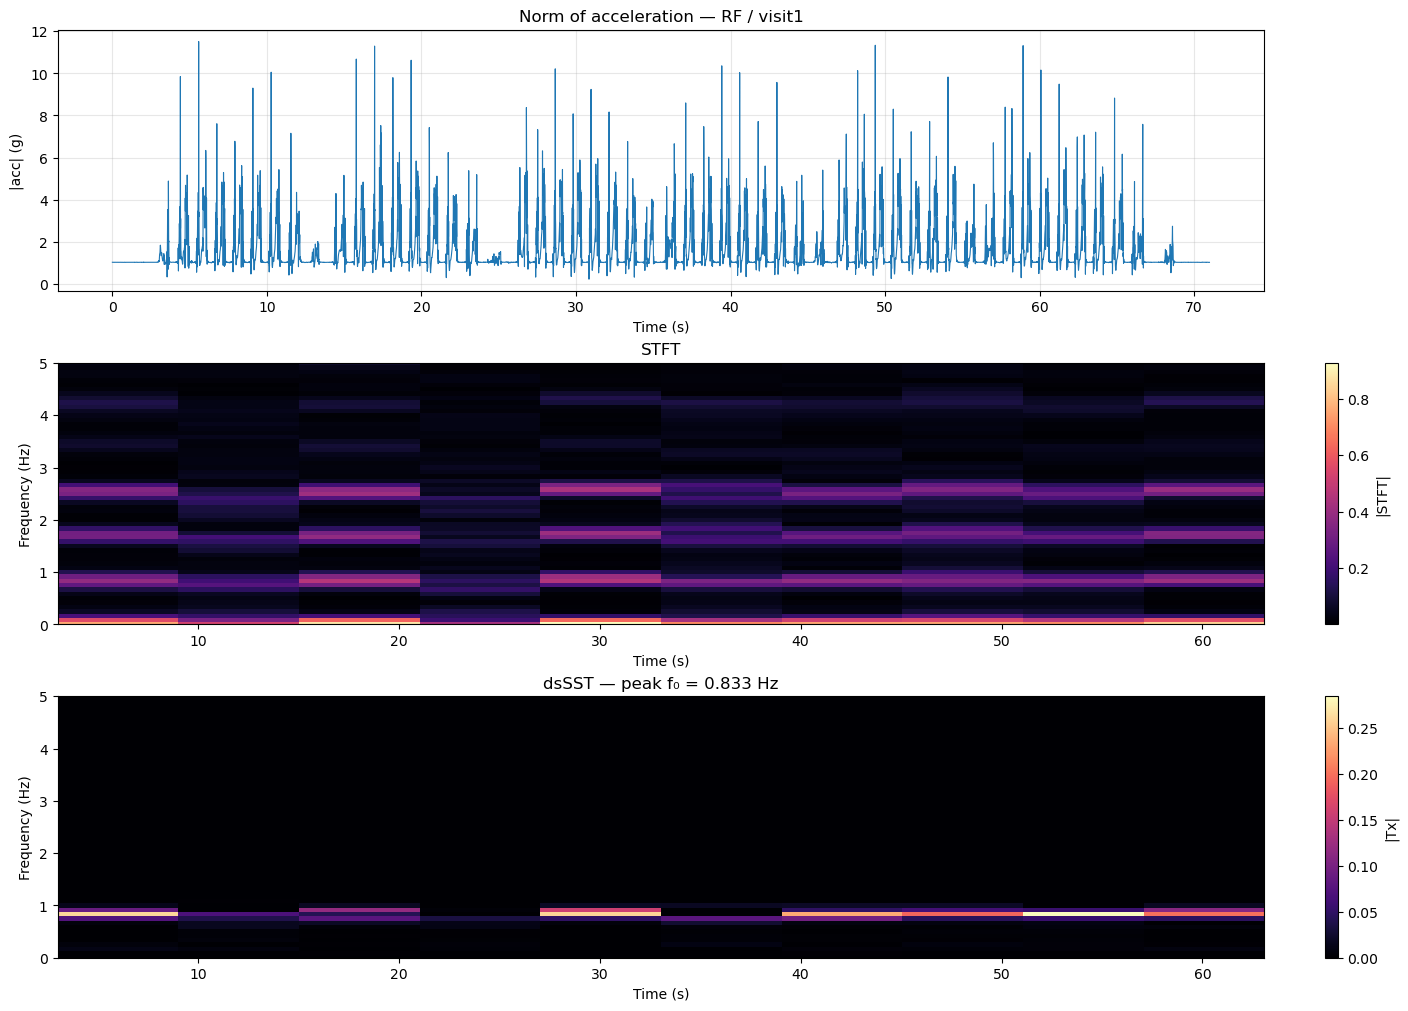

In [ ]:
#------------------d) perform the visualisation of the signal processing of the time frequency analysed on the right foot------------------
"""
This step aim is to visualise the time frequency representation of the signal for the right foot (RF) during the first visit (visit1).
   -----------------------------INPUT----------------------------
    recordings: list of dictionaries containing the information about the recordings, including the norm of acceleration and the analysis results for each recording.
    fs: sampling frequency of the IMU sensor
    output_dir: directory where the figures will be saved
    -----------------------------OUTPUT----------------------------
    plot showing the norm of acceleration, the STFT and the dsSST for the right foot during the first visit.
    The saving of this figure in the result directory.
    """
# focus on the right foot (RF) during the first visit (visit1)
rec_target = next(
    (r for r in recordings 
     if r["visit"] == "visit1" and r["sensor"] == "RF" and r["analysis"] is not None),
    None
)
# Retrieve the data
norm     = rec_target["norm"]
analysis = rec_target["analysis"]
t        = np.arange(len(norm)) / fs               # time vector in seconds


# Step 2 : create the figure with 3 stacked subplots (3 rows × 1 column)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)

# ---- Subplot 1 : norm of acceleration ----
axes[0].plot(t, norm, color='tab:blue', linewidth=0.8)
axes[0].set_title("Norm of acceleration — RF / visit1")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (g)")
axes[0].grid(alpha=0.3)

# ---- Subplot 2 : STFT (V_Zxx) ----
V_Zxx = analysis["V_Zxx"]
V_t   = analysis["V_t"]
V_f   = analysis["V_f"]

img1 = axes[1].pcolormesh(
    V_t, V_f, np.abs(V_Zxx),                        # the amplitude of STFT is used in the visualization
    shading='auto', cmap='magma'
    )
axes[1].set_title("STFT")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_ylim(0, 5)                              # focusing on the physiologically relevant frequency  (0-5 Hz)
fig.colorbar(img1, ax=axes[1], label="Amplitude (g)")

# ---- Subplot 3 : dsSST (Tx) ----
Tx        = analysis["Tx"]
freq_axis = analysis["freq_axis"]

img2 = axes[2].pcolormesh(
    V_t, freq_axis, np.abs(Tx),                        # the amplitude of dsSST is used in the visualization
    shading='auto', cmap='magma'
    )
axes[2].set_title(f"dsSST — peak f₀ = {rec_target['peak_frequency_hz']:.3f} Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_ylim(0, 5)                              # focusing on the physiologically relevant frequency  (0-5 Hz)
fig.colorbar(img2, ax=axes[2], label="Amplitude (g)")

# Optionally : save the figure
save_path = Path(results_dir) / "RF_visit1_analysis.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Figure saved : {save_path}")

plt.show()

### *e)* Create a summary file with the frequency information and the FAC score for every patient visit. 
This file will be used for the statistical analysis in R. The summary file will contain the following columns for every patient visit:
    - "patient_id": the ID of the patient  
    - "visit": the visit number (e.g., 1, 2, 3)  
    - "sensor": the sensor used for the measurement  
    - "duration_s": the duration of the walking trial in seconds  
    - "peak_frequency_hz": the estimated fundamental frequency of walking, extracted from the time-frequency representation of the signal  
    - "FAC": the Functional Ambulation Category score of the patient, imported from the dataset

In [ ]:
#------------------e) Creating a file with the results------------------
"""
In this final step, we will create a summary file that contains the results of our analysis, including the peak frequency extracted from the dsSST analysis for each patient and visit.
    -----------------------------INPUT----------------------------
    recordings: A list of dictionaries, each containing the results of the analysis for each recording, including the patient_id, visit, sensor, peak frequency
    results_dir: Path to the directory where the summary file will be saved
    -----------------------------OUTPUT----------------------------
    A CSV file containing the summary of the analysis, including the peak frequency for each patient and visit.

"""

summary_cols = [ "visit", "sensor", "peak_frequency_hz"]
df_results = pd.DataFrame([
    {k: r[k] for k in summary_cols} for r in recordings
])

csv_out = Path(results_dir) / "frequency_summary.csv"
df_results.to_csv(csv_out, index=False)
print(f"Register frame : {csv_out}")
df_results.head(10)

Register frame : c:\Users\kapla\Documents\r et python\algorithm\algorithm de marche\LAMBERT_CAMILLE\results\frequency_summary.csv


,visit,sensor,peak_frequency_hz
0,visit1,LF,0.832755
1,visit1,RF,0.832755
2,visit1,LW,0.832755
3,visit1,RW,0.832755
4,visit1,SA,0.499653
5,visit2,LF,0.832755
6,visit2,RF,0.832755
7,visit2,LW,0.582929
8,visit2,RW,0.832755
9,visit2,SA,0.832755


## The handle_data module

This module contains functions to extract features from the raw data. This is built to handle the data from the dataset of Zhou and al.  
-'find_patient_visits': to return dictionary information of {visit, imu_dir} in the dataset  
-'load_acc_norm': to load the data of the accelerometer and return the norm of the acceleration and the time of an IMU sensor  
-'Time_frequency_analyse': to apply the deshape synchrosqueezing transform on the norm of the acceleration to extract the fundamental frequency and the cadence of the walk and the time-frequency representation of the signal.  

The function has been made with the help of claude IA. In case of problems, triangualation has been made with Copilot IA  

In [ ]:
def find_patient_visits(data_root: Path):
    """
    Find the data of the dataset in the following path data_root/imuXXXX/visitN/imu/. 
    If the directory does not exist or it's not in the correct format, it is not added to the list.
    ----------------------------INPUT----------------------------
    data_root: Path to the root directory of the dataset, which contains the patient directories (imuXXXX).
    ----------------------------OUTPUT----------------------------
    A list of dictionaries, each containing {visit, imu_dir} for each valid patient visit found in the dataset.
    """
    # Initialize an empty list to store the information about patient visits
    information = []

    # We are going to find the directories of the visits, which are in the format "visitN" where N is a number, and then find the directory "imu" in each visit directory
    # sorted(...) ensures a consistent order of visits (ex: visit1 before visit2)
    for visit_dir in sorted(data_root.iterdir()):
        # Security to take only the directories and not the files that may be in the patient_dir
        if not visit_dir.is_dir():
                continue
        # re.match used to select only the directories beginning with "visit"
        if not re.match(r"visit\d+", visit_dir.name):
            continue
        # Find the "imu" directory within the visit directory
        imu_dir = visit_dir / "imu"
        # Check if the "imu" directory exists and is a directory, if so, add the information to the list
        if imu_dir.is_dir():
                information.append({
                    "visit": visit_dir.name,
                    "imu_dir": imu_dir,
                })
    return information

In [ ]:
def load_acc_norm(csv_path: Path):
    """
    In our work we are going to use only the accelerometer data (accx, accy, accz) and the time of the IMU 
    For the deshape Synchrosqueezing algortihm only the norm is need to extract the fundamental frequency of the walk.
    So this function is used to compute the norm of the acceleration. The norm is the length of the acceleration vector, which is computed as sqrt(accx^2 + accy^2 + accz^2).
    ----------------------------INPUT----------------------------
    csv_path: Path to the csv file containing the raw data of the IMU sensor, which should contain at the columns "timestamp", "accx", "accy", "accz"
    ----------------------------OUTPUT----------------------------
    ts: numpy array containing the time of the IMU sensor, extracted from the "timestamp" column of the csv file.
    norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
    """
    # Security check to ensure that the csv file exists
    if not csv_path.exists():
        return None, None

    # Frist we read the header of the csv file to find the columns we need, and to be able to handle the case where the columns are not in the same order
    # we are using pandas to read the csv file, and we read only the first row (nrows=0) to get the name of the data columns.
    # The columns are selected by .columns and transformed to a list by .tolist()
    colums_name = pd.read_csv(csv_path, nrows=0).columns.tolist()
    # for security we create a dictionary that maps the lowercase version of the column names to handle majuscule/minuscule differences.
    colums_name = {c.lower(): c for c in colums_name}
    # Dictionary of the columns we want extract. We initialise the values to None
    name_wanted = {"timestamp": None, "accx": None, "accy": None, "accz": None }
    # In a this loop we check if the columns we want extract are in the  file
    for key in list(name_wanted.keys()):
        if key in colums_name:
            name_wanted[key] = colums_name[key]
        # If a column is missing, we raise a ValueError with a message indicating which column is missing 
        else:
            raise ValueError(f"Column '{key}' missing in {csv_path.name}")

    # extract the columns we are going to use from the csv file using the name_wanted dictionary, and we convert them to numpy arrays.
    Used_name = list(name_wanted.values())
    df = pd.read_csv(csv_path, usecols=Used_name)

    ts   = df[name_wanted["timestamp"]].to_numpy()
    # we specify dtype=float to ensure that the data is in the correct format for the computation of the norm
    ax   = df[name_wanted["accx"]].to_numpy(dtype=float)
    ay   = df[name_wanted["accy"]].to_numpy(dtype=float)
    az   = df[name_wanted["accz"]].to_numpy(dtype=float)
    norm = np.sqrt(ax**2 + ay**2 + az**2)
    return ts, norm


In [ ]:
def Time_frequency_analyse(signal_norm, fs, **dsSST_paramaters):
    """Application of the dsSST on the accelerometer norm to find the cadence and the fundamental frequency.
    -----------------------------INPUT----------------------------
    signal_norm: numpy array containing the norm of the acceleration, computed from the "accx", "accy", "accz" columns of the csv file.
    fs: sampling frequency of the IMU sensor
    dsSST_paramaters : parameter to compute the deshape synchrosqueezing transform.
        It should contain the following keys:
        - "gamma": the gamma parameter of the dsSST is the threshold for the synchrosqueezing step
        - "lambda_reg": penalization parameter for the extraction by recurrence 
        - "lifter_threshold": the threshold for the lifting step, which is used to remove the low quefrency components of the signal.
        - "window_length_s": the length of the window used for the short-time Fourier transform (STFT) in seconds.
    -----------------------------OUTPUT----------------------------
    A dictionary containing the following keys:
    - "f0_freq_hz": the fundamental frequency of the walk, extracted from the deshape synchrosqueezing transform of the signal.
    - "cadence": the cadence of the walk, computed from the fundamental frequency as cadence = f0_freq_hz*2
    - "V_Zxx": the deshape synchrosqueezing transform of the signal, which is a time-frequency representation of the signal.
    - "V_f": the frequency axis of the deshape synchrosqueezing transform
    - "V_t": the time axis of the deshape synchrosqueezing transform
    - "Tx": the time-frequency representation of the signal obtained by applying the deshape synchrosqueezing transform
    - "freq_axis": the frequency axis of the deshape synchrosqueezing transform

    """
    result = dsSST(signal_norm, fs, **dsSST_paramaters)
    if result is None:
        return None
    (peak_frequency_hz,
     V_Zxx, V_f, V_t,
     C_lifted, U, W,
     Tx, freq_axis) = result
    return {
        "peak_frequency_hz":      peak_frequency_hz,
        "V_Zxx": V_Zxx, "V_f": V_f, "V_t": V_t,
        "C_lifted": C_lifted, "U": U, "W": W,
        "Tx": Tx, "freq_axis": freq_axis,
    }


## The dsSST pipeline

The algorithm of de shape synchrosequeezing is based on the work of Hau Tieng Wu and Chen-Yun Lin to analyse a non stationary signal with two non linear combined methods.  
The STC (short time cepstrum) and the iSTC (inverse shor time cepstrum) combined with SST (synchrosqueezing)  
The aim of this algorithm is to find the cadence during the gait by mutiple the instantaneous frequency by two  

The ssquezepy is needed for the SST it have been done by John Muradeli, ssqueezepy, 2020. GitHub repository, https://github.com/OverLordGoldDragon/ssqueezepy/. DOI: 10.5281/zenodo.5080508  

The algorithm has 6 different steps:  
1. preprocessing the data by detrend and butterworth them  
2. Compute the STFT of the signal (V_Zxx)  
3. Compute the STC of the signal and the iSTC of the signal (C_lifted, U)  
4. Compute the deshape STFT by a hadamard product between the STFT and the iSTC (W)  
5. Compute the synchrosqueezing of the deshape STFT (dsSST)  
6. Extract the curve of dsSST  
7. Compute the instantaneous frequency  

Your input needs his : Signal_norm ,frequency, 
The output are : instantaneous_frequency, V_Zxx, C_lifted, U, W, dsSST  

In [ ]:
def dsSST(Signal_norm ,frequency,gamma=10**-9,lambda_reg=1,lifter_threshold=10,window_length_s=12):

    # -------------------------------------------------------------------------
    # Step 1 : Preprocessing
    # -------------------------------------------------------------------------
    #detrend and butterworth the signal

    f = np.asarray(Signal_norm, dtype=float).copy()

    # Interpolate NaN values
    nan_mask = np.isnan(f)
    if np.any(nan_mask):
        valid = ~nan_mask
        if np.sum(valid) < 2:
            return None
        idx_arr = np.arange(len(f), dtype=float)
        f[nan_mask] = np.interp(idx_arr[nan_mask], idx_arr[valid], f[valid])

    # Article: "detrend by the standard median filter with order 10*fs"
    median_order = int(10 * frequency)
    if median_order % 2 == 0:
        median_order += 1
    trend = signal.medfilt(f, kernel_size=median_order)
    f_detrended = f - trend

    # Article: "rectify the detrended signal (take the magnitude)"
    f_rect = np.abs(f_detrended)

    # b, a = signal.butter(4, 0.5 / (frequency / 2), btype='highpass')
    # sig = signal.filtfilt(b, a, f_rect)

    # -------------------------------------------------------------------------
    # Step 2 : STFT
    # -------------------------------------------------------------------------
    #than do the stft of the signal to have the V matrix for the hadamard product with the iSTC
    nperseg = int(frequency * window_length_s)
    K = nperseg // 2
    window_len = 2 * K + 1

    # Exact construction according to the paper
    k = np.arange(1, window_len + 1)
    sigma = 0.15  # free parameter, to be tested

    h_window = np.exp(-((k - 1) / (2 * K) - 0.5) ** 2 / (2 * sigma ** 2))

    V_f, V_t, V_Zxx = V=signal.stft(x=f_rect,
              fs=frequency,
              window=h_window,
              nperseg=window_len,
              noverlap=window_len // 2,
              nfft=None,
              return_onesided=True,
              boundary=None,
              padded=False,
              axis=-1)
    
    
    # -------------------------------------------------------------------------
    # Step 3 : STC + iSTC
    # -------------------------------------------------------------------------
    #compute the stc of the signal and the iSTC of the signal
    espilon = 1e-12
    V_Zxx_modulate=np.abs(V_Zxx)**0.3# modulate by a power law to enhance the fundamental frequency component in the cepstrum like in the paper of Hau Tieng Wu and Chen-Yun Lin
    C = np.fft.fft(V_Zxx_modulate, axis=0)# the cepstrum can be done by a ifft or a fft , we do a fft like in the paper of Hau Tieng Wu and Chen-Yun Lin 
    
    """the iSTCT is numerically unstable to stabilise it you have two solution:
    .do a long long-pass lifter of the cepstrum to isolate the fundamental quefrency component in the cepstrum 
    .discretize I by a suitable weighting, for example, by the Jacobian of I, so that the iSTCT is defined on the uniform frequency grid."""
    
    # Borne haute de fréquence qu'on veut laisser passer dans U(f)
    # Exclude the quefrencies below this threshold, normally between [10,20] according to Lin et al. 2018
    C_lifted = np.copy(C)
    C_lifted[:lifter_threshold, :] = 0  # We want to do a long long-pass lifter to isolate the fundamental quefrency component in the cepstrum
    
    # inverse short time cepstrum
    # iSTCT by inverse-axis interpolation: U(f) = C(q=1/f)
    # Build quefrency axis from STFT frequency step
    # iSTC: U(f) = C(q=1/f)  — evaluate cepstrum at quefrency q = 1/f
    N= len(V_f)
    delta_f =(V_f[1] - V_f[0])  # resolution in quefrency

    q_axis=np.arange(N)/(N*delta_f)  # quefrency axis
    U=interpolate.interp1d(q_axis, C_lifted, axis=0, bounds_error=False, fill_value=0)((1.0 / V_f))
    
    # -------------------------------------------------------------------------
    # Step 4 : Deshape STFT (Hadamard product)
    # -------------------------------------------------------------------------
    # Deshape STFT by a Hadamard product between V and U
    """The deshape STFT is computed by a Hadamard product between the STFT and the iSTC, 
    it is a way to enhance the fundamental frequency component in the STFT by multiplying it with the iSTC 
    which have been lifter to isolate the fundamental quefrency component in the cepstrum"""

    W = (V_Zxx) * (U)

    # -------------------------------------------------------------------------
    # Step 5 : Synchrosqueezing
    # -------------------------------------------------------------------------
    # compute the synchrosqueezing of the deshape STFT

    dWx = np.gradient(W, V_t, axis=1, edge_order=2)# compute the derivative of W with respect to time
    dsSST = ss.ssqueeze(
        Wx=W,# the signal to be synchrosqueezed, in our case the deshape STFT            
        w=None,
        ssq_freqs=V_f,
        scales=None,  # we provide the frequencies, so ssqueeze won't compute the scales internally
        dWx=dWx,  # we provide the derivative dWx, so ssqueeze won't compute it internally
        Sfs=V_f,
        gamma=gamma,# lower threshold to avoid suppressing almost all energy
        transform='stft',
        fs=frequency,
        squeezing='sum',
        maprange='maximal'
        )
    # Tx: time frequency representation of the deshape STFT, it is a 2D array where the first dimension is the frequency and the second dimension is the time
    Tx = np.asarray(dsSST[0])
    freq_axis = np.asarray(dsSST[1])
    power = np.abs(Tx) ** 2

    # -------------------------------------------------------------------------
    # Step 6 : Extraction of the c* curve by dynamic programming
    # -------------------------------------------------------------------------
    """
    The curve c* is the curve that maximizes the energy in the synchrosqueezed representation while penalizing rapid changes in frequency. 
       c* = argmax  Σ log(|SW(c(m), m)| / Σ_j |SW(j, m)|)- λ Σ |c(m) - c(m-1)|

    The first term sets the curve to follow the maximum energy in the synchrosqueezed representation, 
    while the second term penalizes rapid changes in frequency by adding a regularization term 
    that is proportional to the absolute difference between the current frequency bin and the previous frequency bin.

    The dynamic processing follows a Viterbi-like algorithm where we compute a score matrix that is the sum of the log of the energy 
    and we capture the backtrack to extract the curve c* that maximizes the score.

    """
    # Preparation
    SW    = Tx.T                    # [N_time, N_freq] — no more restriction
    interval_len = SW.shape[0]        # N_time
    M_band       = SW.shape[1] - 1   # all frequency bins
    # Frame normalisation: for each time step m, the value is divided by the sum of the amplitudes in the frame. 
    # This makes the functional comparable across frames (each frame contributes equally, regardless of its absolute amplitude).
    denom_per_frame = np.abs(SW).sum(axis=1)  # [N_time]
    denom_per_frame = np.maximum(denom_per_frame, 1e-12)  # protection 

    # Initialization by calculating the frequency resolution and the regularization cost
    # df[m, k]        : best score for a path ending at c(m) = k.
    # backtrack[m, k] : best predecessor c(m-1) that maximizes df[m, k].

    df        = np.full((interval_len, M_band + 1), -np.inf) # [N_temps, N_freq]
    backtrack = np.zeros((interval_len, M_band + 1), dtype=int)  # sur tous les bins fréquentiels permet de le faire localement
    
    # Matric cost of regularization (total variation penalty) for transitions between frequency bins:
    # reg_matrix[k, k'] = λ * |k - k'|
    # Penalizes transitions from bin k' to bin k proportionally to their distance.
    c_range   = np.arange(M_band + 1)
    reg_matrix = lambda_reg * np.abs(c_range[:, None] - c_range[None, :])
    # Initialization of the first time step (m=0) by the log of the normalized energy in the synchrosqueezed representation for each frequency bin:
    df[0, :] = np.log(np.abs(SW[0, :]) / denom_per_frame[0] + 1e-12)

    # ---- Forward recurrence ----
    # At each time step, for each target bin k, we look for the best
    # previous bin k' that maximizes (score at time m-1 - transition cost).
    for t in range(1, interval_len):
        # normalized energy at the current frame (data attachment term)
        log_terms       = np.log(np.abs(SW[t, :]) / denom_per_frame[t] + 1e-12)
        # scores[k, k'] = df[t-1, k'] - λ |k - k'|
        scores_matrix   = df[t-1, :][None, :] - reg_matrix
        # for each target k, we keep the optimal k'
        backtrack[t, :] = np.argmax(scores_matrix, axis=1)
        # update : score = data attachment term + best transition score
        df[t, :]        = log_terms + scores_matrix[c_range, backtrack[t, :]]

    # ---- "Backtracking" : build optimal path ----
    # We start from the final time step (choosing the best bin), then move backward in time following the predecessors stored in `backtrack`.
    c_opt     = np.zeros(interval_len, dtype=int)
    c_opt[-1] = np.argmax(df[-1, :])
    for t in range(interval_len - 2, -1, -1):
        c_opt[t] = backtrack[t + 1, c_opt[t + 1]]

    # -------------------------------------------------------------------------
    # Step 7 : Instantaneous frequency and fundamental frequency
    # -------------------------------------------------------------------------
    # Conversion of c* indices to real frequencies (Hz)
    instantaneous_frequency = freq_axis[c_opt]  # equivalent to c_opt * (fs / 2M)
    median_instantaneous_frequency = float(np.median(instantaneous_frequency[instantaneous_frequency > 0]))

    return (
        median_instantaneous_frequency,
        V_Zxx, V_f, V_t,
        C_lifted, U, W,
        Tx, freq_axis
    )

## Bibliography

Wu, Hau-Tieng, et Jaroslaw Harezlak. « Application of de-shape synchrosqueezing to estimate gait cadence from a single-sensor accelerometer placed in different body locations ». Physiological Measurement 44, nᵒ 5 (2023): 055009.  
Lin, Chen-Yun, Su Li, et Hau-Tieng Wu. « Wave-Shape Function Analysis -- When Cepstrum Meets Time-Frequency Analysis | Request PDF ». ResearchGate, publication en ligne anticipée, 5 août 2025. https://doi.org/10.1007/s00041-017-9523-0.  
Zhou, Lin, Torsten Rackoll, Lennard Ekrod, et al. « Dataset for Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors (IMU) ». Zenodo, 19 janvier 2024. https://doi.org/10.5281/zenodo.10534055.  
Zhou, Lin, Torsten Rackoll, Lennard Ekrod, et al. « Monitoring and Visualizing Stroke Rehabilitation Progress using Wearable Sensors ». 2024 46th Annual International Conference of the IEEE Engineering in Medicine and Biology Society (EMBC), juillet 2024, 1‑6. https://doi.org/10.1109/EMBC53108.2024.10782489.  


Muradeli, John. OverLordGoldDragon/ssqueezepy. Python. 29 janvier 2020, released 2 février 2026. https://github.com/OverLordGoldDragon/ssqueezepy.  
« pandas.melt — pandas 3.0.2 documentation ». Consulté le 29 avril 2026. https://pandas.pydata.org/docs/reference/api/pandas.melt.html.
« pandas.read_csv — pandas 3.0.2 documentation ». Consulté le 28 avril 2026. https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html.  